In [13]:
from pathlib import Path
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import butter, hilbert, sosfiltfilt
import scipy.io as sio
import time
import matplotlib.gridspec as gridspec
from scipy.interpolate import make_interp_spline

# Parámetros del registro
n_channels = 16
fs = 2500  # Hz
pitch = 100e-6  # Distancia entre contactos del probe (100 µm)

# Filtro Butterworth (100-300 Hz)
f_low, f_high = 100, 300
sos_ripple = butter(4, [f_low, f_high], btype="band", fs=fs, output="sos")

# Parámetros de la ventana (50 ms a cada lado para visualizar bien la dinámica)
ventana_ms = 30
puntos_ventana = int((ventana_ms / 1000) * fs)  # 125 puntos
tiempo = np.linspace(-ventana_ms, ventana_ms, (puntos_ventana * 2) + 1) / 1000  # en segundos (-0.05 a 0.05)

# Ruta principal
carpeta_principal = Path(r"D:\Violeta\ANALISIS")
archivos_dat = list(carpeta_principal.rglob("LFP_downsampled.dat"))

In [10]:
# ============================================================
# LOCALIZAR Y COMPROBAR TODAS LAS SESIONES
# ============================================================

# Carpeta principal donde están todos los grupos y sesiones
carpeta_principal = Path(r"D:\Violeta\ANALISIS")

# Buscar todos los archivos LFP_downsampled.dat dentro de ANALISIS
archivos_lfp = sorted(carpeta_principal.rglob("LFP_downsampled.dat"))

# Aquí guardaremos únicamente las sesiones que tengan
# TODOS los archivos necesarios para nuestro análisis
sesiones_validas = []

# Aquí guardaremos las sesiones que tengan algún archivo necesario
# pero les falte otro
sesiones_incompletas = []


# ------------------------------------------------------------
# Revisamos una por una las sesiones encontradas
# ------------------------------------------------------------

for archivo_lfp in archivos_lfp:

    # La carpeta que contiene LFP_downsampled.dat
    carpeta_sesion = archivo_lfp.parent

    # Archivos que necesitamos en esa misma sesión
    archivo_csd = carpeta_sesion / "rippleCSDs.mat"
    archivo_ripple_analysis = (
        carpeta_sesion / "analyset" / "rippleAnalysis.mat"
    )

    # Comprobar que existen los tres archivos
    tiene_lfp = archivo_lfp.exists()
    tiene_csd = archivo_csd.exists()
    tiene_ripple = archivo_ripple_analysis.exists()

    if tiene_lfp and tiene_csd and tiene_ripple:

        # Guardamos toda la información importante de la sesión
        sesiones_validas.append({
            "grupo": carpeta_sesion.parent.name,
            "sesion": carpeta_sesion.name,
            "carpeta": carpeta_sesion,
            "lfp": archivo_lfp,
            "csd": archivo_csd,
            "ripple_analysis": archivo_ripple_analysis
        })

    else:

        # Guardamos las sesiones incompletas para poder revisarlas
        sesiones_incompletas.append({
            "grupo": carpeta_sesion.parent.name,
            "sesion": carpeta_sesion.name,
            "carpeta": carpeta_sesion,
            "lfp": archivo_lfp,
            "tiene_csd": tiene_csd,
            "tiene_ripple": tiene_ripple
        })


# ------------------------------------------------------------
# Ordenar las sesiones por grupo y después por nombre de sesión
# ------------------------------------------------------------

sesiones_validas = sorted(
    sesiones_validas,
    key=lambda x: (x["grupo"], x["sesion"])
)

sesiones_incompletas = sorted(
    sesiones_incompletas,
    key=lambda x: (x["grupo"], x["sesion"])
)

# ------------------------------------------------------------
# Mostrar un resumen
# ------------------------------------------------------------

print("=" * 70)
print("BÚSQUEDA DE SESIONES")
print("=" * 70)

print(f"\nCarpeta principal:")
print(carpeta_principal)

print(f"\nArchivos LFP encontrados: {len(archivos_lfp)}")
print(f"Sesiones válidas: {len(sesiones_validas)}")

# ------------------------------------------------------------
# Contar cuántas sesiones hay de cada grupo
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("SESIONES VÁLIDAS POR GRUPO")
print("-" * 70)

grupos = sorted(set(s["grupo"] for s in sesiones_validas))

for grupo in grupos:

    numero_sesiones = sum(
        s["grupo"] == grupo
        for s in sesiones_validas
    )

    print(f"{grupo}: {numero_sesiones} sesiones")


print("\n" + "=" * 70)


BÚSQUEDA DE SESIONES

Carpeta principal:
D:\Violeta\ANALISIS

Archivos LFP encontrados: 164
Sesiones válidas: 93

----------------------------------------------------------------------
SESIONES VÁLIDAS POR GRUPO
----------------------------------------------------------------------
EFV_218: 7 sesiones
EFV_220: 8 sesiones
EFV_263: 2 sesiones
EFV_277: 7 sesiones
EFV_279: 6 sesiones
EFV_280: 8 sesiones
NPC_249: 9 sesiones
NPC_250: 9 sesiones
NPC_262: 13 sesiones
NPC_28: 3 sesiones
NPC_29: 3 sesiones
NPC_30: 3 sesiones
NPC_47: 2 sesiones
NPC_48: 3 sesiones
WT_23: 3 sesiones
WT_35: 3 sesiones
WT_90: 4 sesiones



In [8]:
def procesar_csd_ripple(archivo_csd, pct_ventana=0.2):
    """
    Carga el archivo .mat con la estructura 'rippleCSDs', calcula el CSD medio
    en el tiempo y genera el perfil vertical por canal.
    
    Parámetros:
        archivo_csd (str o Path): Ruta al archivo 'rippleCSDs.mat'.
        pct_ventana (float): Porcentaje de la ventana temporal centrado en el pico.
        
    Retorna:
        csd_matrix (ndarray): Matriz 2D de CSD [canales, tiempo].
        csd_medio_canal (ndarray): Perfil vertical de CSD [canales].
        tiempo (ndarray): Array con los puntos de tiempo.
    """
    # 1. Cargar el archivo .mat
    mat_csd = sio.loadmat(archivo_csd)
    ripple_struct = mat_csd['rippleCSDs'][0, 0]

    # 2. Extraer el vector de tiempo y la matriz 3D (tiempo, canales, nºripples)
    tiempo = ripple_struct['t'].flatten()  # Array de tiempo en ms
    csd_raw = ripple_struct['CSDs']         # Matriz 3D (251, 13, 270)

    # 3. Promediar sobre los ripples (eje 2), aplicar signo y transponer -> [canales, tiempo]
    csd_matrix = -1 * np.mean(csd_raw, axis=2).T

    # 4. Dimensiones dinámicas (se adapta según la sesión/ratón)
    n_canales, n_muestras = csd_matrix.shape

    # 5. Ventana central del ripple
    centro = n_muestras // 2
    ancho_ventana = int(n_muestras * pct_ventana)
    csd_ventana = csd_matrix[:, centro - ancho_ventana : centro + ancho_ventana]

    # 6. Promedio por canal (perfil vertical)
    csd_promedio_canal = np.mean(csd_ventana, axis=1)

    return csd_matrix, csd_promedio_canal

In [12]:
# 2. BUCLE PRINCIPAL
sesiones_procesadas = []
t_inicio_total = time.time()

print("🚀 Iniciando procesamiento rápido en memoria...")

# Iteramos directamente sobre las sesiones confirmadas
for idx, info_sesion in enumerate(sesiones_validas, 1):
    carpeta_sesion = info_sesion["carpeta"]
    archivo_lfp_dat = info_sesion["lfp"]
    archivo_csd = info_sesion["csd"]
    archivo_ripple_analysis = info_sesion["ripple_analysis"]
    grupo = info_sesion["grupo"]

    # --- A. LEER LFP (.dat) ---
    datos_brutos = np.fromfile(archivo_lfp_dat, dtype=np.int16)
    muestras_incompletas = len(datos_brutos) % n_channels
    if muestras_incompletas != 0:
        datos_brutos = datos_brutos[:-muestras_incompletas]
    datos_matriz = datos_brutos.reshape(-1, n_channels)
    puntos_de_tiempo = datos_matriz.shape[0]

    # --- B. LEER RIPPLE ANALYSIS (.mat) ---
    try:
        with h5py.File(archivo_ripple_analysis, "r") as f:
            irips_matlab = f["rippleAnalysis"]["iRipS"][:].T
        irips_python = irips_matlab.astype(int) - 1

        if irips_python.ndim == 1:
            irips_python = np.atleast_2d(irips_python)
            if irips_python.shape[0] == 2 and irips_python.shape[1] != 2:
                irips_python = irips_python.T
    except Exception:
        continue

    # --- C. LEER CSD PRECALCULADO ---
    try:
        csd_medio, csd_promedio_canal = procesar_csd_ripple(archivo_csd)
    except Exception as e:
        print(f"⚠️ Error al leer CSD en {info_sesion['sesion']}: {e}")
        continue

    # --- D. FILTRADO Y EXTRACCIÓN DE VENTANAS ---
    datos_filtrados = sosfiltfilt(sos_ripple, datos_matriz, axis=0)
    lista_filt = []

    for inicio, fin in irips_python:
        segmento_orig = datos_filtrados[inicio:fin, :]
        if segmento_orig.shape[0] > 0:
            amplitud_por_canal = np.max(np.abs(segmento_orig), axis=0)
            canal_maximo = np.argmax(amplitud_por_canal)

            pico_relativo = np.argmax(np.abs(segmento_orig[:, canal_maximo]))
            idx_pico_global = inicio + pico_relativo

            nuevo_inicio = idx_pico_global - puntos_ventana
            nuevo_fin = idx_pico_global + puntos_ventana + 1

            if nuevo_inicio >= 0 and nuevo_fin <= puntos_de_tiempo:
                lista_filt.append(datos_filtrados[nuevo_inicio:nuevo_fin, :])

    if len(lista_filt) == 0:
        continue

    matriz_filt = np.array(lista_filt)

    # --- E. HILBERT, POWER Y MÉTRICAS ---
    envolvente_recortes = np.abs(hilbert(matriz_filt, axis=1))
    matriz_power = envolvente_recortes**2

    lfp_medio_filt = np.mean(matriz_filt, axis=0)
    power_medio = np.mean(matriz_power, axis=0)

    amplitudes_por_ripple = np.ptp(matriz_filt, axis=1)
    if amplitudes_por_ripple.ndim == 1:
        amplitudes_por_ripple = np.atleast_2d(amplitudes_por_ripple)

    max_ampl_canal = np.max(amplitudes_por_ripple, axis=0)
    mean_ampl_canal = np.mean(amplitudes_por_ripple, axis=0)
    power_peak_canal = np.max(power_medio, axis=0)

    canal_max_power = np.argmax(power_peak_canal)
    canal_pyr = np.argmax(mean_ampl_canal)

    # Capas estimadas
    n_ch_sesion = lfp_medio_filt.shape[1]
    capas = []
    for ch in range(n_ch_sesion):
        if ch <= canal_pyr - 2:
            capas.append("Or")
        elif ch == canal_pyr:
            capas.append("Pyr")
        elif ch <= canal_pyr + 3:
            capas.append("Rad")
        else:
            capas.append("SLM")

    # --- F. GUARDAR EN RAM (Incluyendo el grupo para análisis comparativo) ---
    carpeta_resultados = carpeta_sesion / "ProcesamientoNatalia"
    sesiones_procesadas.append({
        "grupo": grupo,
        "sesion": info_sesion["sesion"],
        "carpeta": carpeta_sesion,
        "carpeta_resultados": carpeta_resultados,
        "lfp_filt": lfp_medio_filt,
        "csd_medio": csd_medio,
        "power_medio": power_medio,
        "mean_ampl": mean_ampl_canal,
        "max_ampl": max_ampl_canal,
        "power_peak": power_peak_canal,
        "csd_promedio_canal": csd_promedio_canal,
        "canal_pyr": canal_pyr,
        "canal_max_power": canal_max_power,
        "capas": capas,
    })

    print(
        f"[{idx}/{len(sesiones_validas)}] [{grupo}] {info_sesion['sesion']} -> {len(matriz_filt)} ripples procesados"
    )

tiempo_total = time.time() - t_inicio_total
print(
    f"\n⚡ ¡PROCESAMIENTO FINALIZADO EN {tiempo_total:.1f} SEGUNDOS ({tiempo_total/60:.1f} MIN)!"
)

🚀 Iniciando procesamiento rápido en memoria...
[1/93] [EFV_218] 2026-01-12_18-02-06 -> 67 ripples procesados
[2/93] [EFV_218] 2026-01-13_12-08-49 -> 25 ripples procesados
[3/93] [EFV_218] 2026-01-13_13-09-16 -> 44 ripples procesados
[4/93] [EFV_218] 2026-01-15_11-14-47 -> 30 ripples procesados
[5/93] [EFV_218] 2026-01-15_11-56-40 -> 25 ripples procesados
[6/93] [EFV_218] 2026-01-15_12-33-45 -> 66 ripples procesados
[7/93] [EFV_218] 2026-01-16_17-50-35 -> 40 ripples procesados
[8/93] [EFV_220] 2026-01-12_16-58-15 -> 105 ripples procesados
[9/93] [EFV_220] 2026-01-13_14-12-19 -> 35 ripples procesados
[10/93] [EFV_220] 2026-01-13_15-18-23 -> 29 ripples procesados
[11/93] [EFV_220] 2026-01-14_11-44-04 -> 104 ripples procesados
[12/93] [EFV_220] 2026-01-14_12-37-30 -> 90 ripples procesados
[13/93] [EFV_220] 2026-01-15_17-57-21 -> 32 ripples procesados
[14/93] [EFV_220] 2026-01-15_18-37-42 -> 88 ripples procesados
[15/93] [EFV_220] 2026-01-16_16-53-48 -> 13 ripples procesados
[16/93] [EFV_26

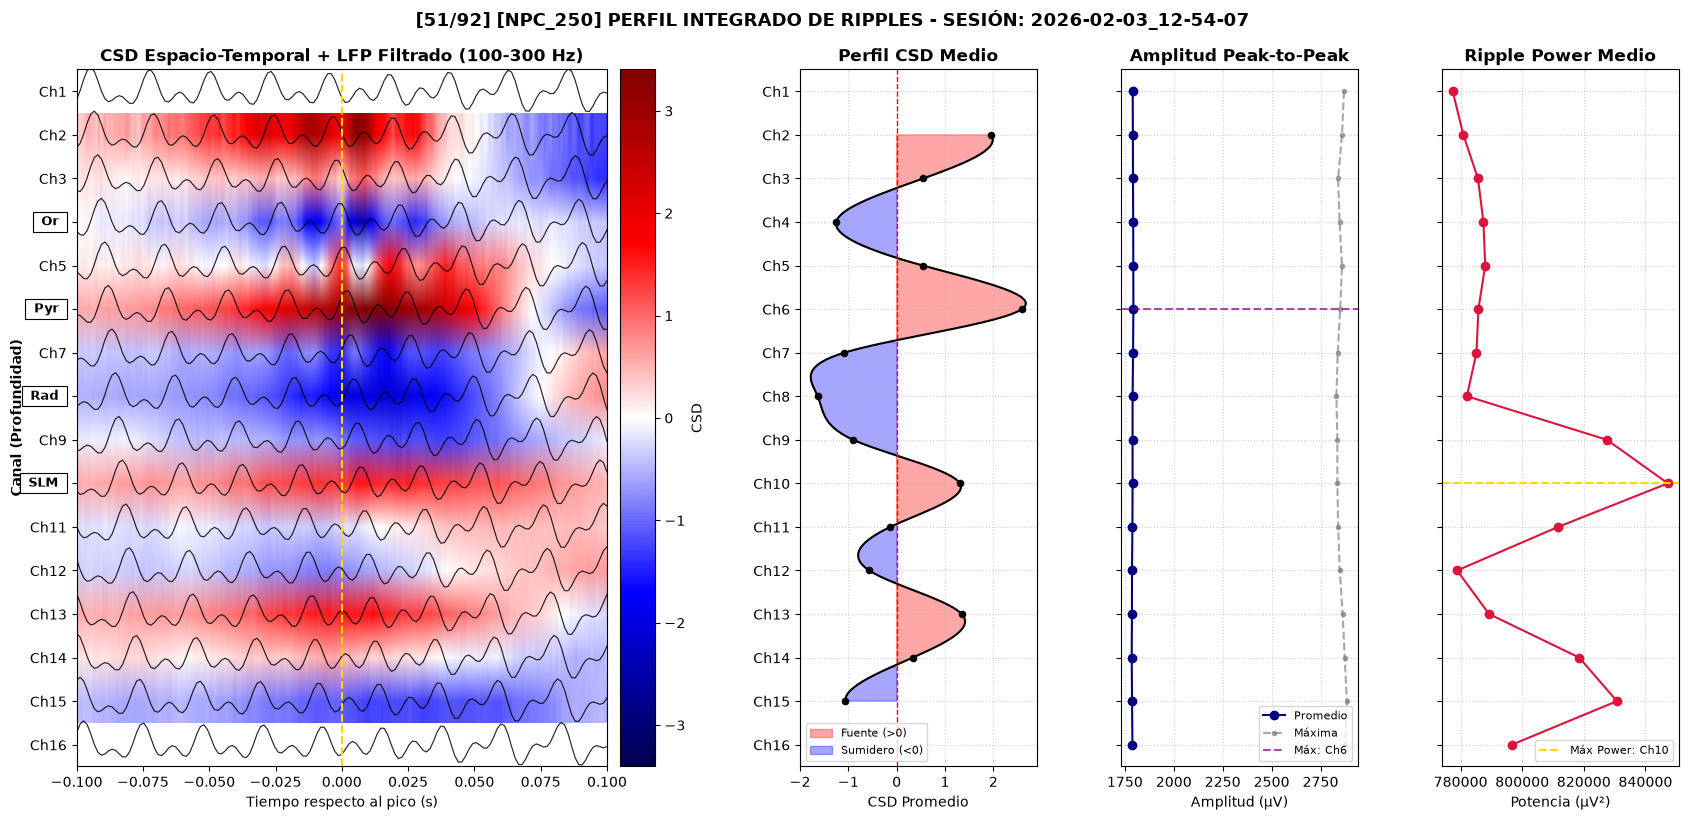

In [20]:
def mostrar_sesion(session_idx=0, fs=2000, puntos_ventana=200):
    s = sesiones_procesadas[session_idx]
    fig = plt.figure(figsize=(18, 8.5))
    gs = gridspec.GridSpec(1, 4, width_ratios=[2.7, 1, 1, 1], wspace=0.25)

    n_channels_lfp = s["lfp_filt"].shape[1]
    canales_lfp = np.arange(1, n_channels_lfp + 1)

    # Vector de tiempo para el LFP filtrado
    tiempo_ms = np.linspace(
        -puntos_ventana / fs, puntos_ventana / fs, s["lfp_filt"].shape[0]
    )

    # --- DATOS CSD Y DETECCIÓN DE CANALES ---
    csd_matriz = s["csd_medio"]
    if csd_matriz.shape[0] != n_channels_lfp and csd_matriz.shape[1] == n_channels_lfp:
        csd_matriz = csd_matriz.T

    n_channels_csd = csd_matriz.shape[0]

    # Calcular los canales a los que corresponde el CSD (centrados si hay pérdida por bordes)
    offset = (n_channels_lfp - n_channels_csd) // 2
    canales_csd = np.arange(1 + offset, n_channels_csd + 1 + offset)

    # ----------------------------------------------------
    # PANEL 1: CSD Espacio-Temporal
    # ----------------------------------------------------
    ax1 = fig.add_subplot(gs[0])

    vmax = np.max(np.abs(csd_matriz))
    n_puntos_csd = csd_matriz.shape[1]
    tiempo_csd = np.linspace(tiempo_ms[0], tiempo_ms[-1], n_puntos_csd)

    # extent ajustado según los canales donde aplica el CSD
    im = ax1.imshow(
        csd_matriz,
        extent=[
            tiempo_csd[0],
            tiempo_csd[-1],
            canales_csd[-1] + 0.5,
            canales_csd[0] - 0.5,
        ],
        aspect="auto",
        cmap="seismic",
        vmin=-vmax,
        vmax=vmax,
        interpolation="bilinear",
    )

    # Superponer LFP filtrado (16 canales completos)
    for ch in range(n_channels_lfp):
        lfp_ch = s["lfp_filt"][:, ch]
        norm_lfp = lfp_ch / (np.max(np.abs(s["lfp_filt"])) * 1.8)
        ax1.plot(
            tiempo_ms,
            (ch + 1) - norm_lfp,
            color="black",
            linewidth=0.85,
            alpha=0.85,
        )

    ax1.axvline(0, color="gold", linestyle="--", linewidth=1.5)
    ax1.set_ylim(n_channels_lfp + 0.5, 0.5)
    ax1.set_yticks(canales_lfp)
    ax1.set_yticklabels([f"Ch{i}" for i in canales_lfp])
    ax1.set_title(
        "CSD Espacio-Temporal + LFP Filtrado (100-300 Hz)", fontweight="bold"
    )
    ax1.set_xlabel("Tiempo respecto al pico (s)")
    ax1.set_ylabel("Canal (Profundidad)", fontweight="bold")

    # Cajas de Capas
    ch_p = s["canal_pyr"] + 1
    pos_capas = {
        "Or": max(1, ch_p - 2),
        "Pyr": ch_p,
        "Rad": min(n_channels_lfp, ch_p + 2),
        "SLM": min(n_channels_lfp, ch_p + 4),
    }

    for label, y_pos in pos_capas.items():
        if 1 <= y_pos <= n_channels_lfp:
            ax1.text(
                tiempo_csd[0] - 0.005,
                y_pos,
                f" {label} ",
                fontsize=9,
                fontweight="bold",
                va="center",
                ha="right",
                bbox=dict(
                    boxstyle="square,pad=0.3",
                    facecolor="white",
                    edgecolor="black",
                    lw=0.8,
                ),
            )

    cbar = fig.colorbar(im, ax=ax1, orientation="vertical", pad=0.02)
    cbar.set_label("CSD")

    # ----------------------------------------------------
    # PANEL 2: Perfil CSD Medio Suavizado (Ajustado a canales_csd)
    # ----------------------------------------------------
    ax2 = fig.add_subplot(gs[1], sharey=ax1)

    y_canales_csd = canales_csd.astype(float)
    x_csd = s["csd_promedio_canal"]

    y_smooth = np.linspace(y_canales_csd.min(), y_canales_csd.max(), 200)
    spline = make_interp_spline(y_canales_csd, x_csd, k=3)
    x_smooth = spline(y_smooth)

    ax2.plot(x_smooth, y_smooth, color="black", linewidth=1.5)
    ax2.scatter(x_csd, y_canales_csd, color="black", s=20, zorder=3)
    ax2.axvline(0, color="red", linestyle="--", linewidth=1)

    ax2.fill_betweenx(
        y_smooth,
        x_smooth,
        0,
        where=(x_smooth > 0),
        color="red",
        alpha=0.35,
        label="Fuente (>0)",
    )
    ax2.fill_betweenx(
        y_smooth,
        x_smooth,
        0,
        where=(x_smooth < 0),
        color="blue",
        alpha=0.35,
        label="Sumidero (<0)",
    )

    ax2.set_title("Perfil CSD Medio", fontweight="bold")
    ax2.set_xlabel("CSD Promedio")
    ax2.legend(loc="lower left", fontsize=8)
    ax2.grid(True, linestyle=":", alpha=0.6)
    ax2.tick_params(labelleft=True)
    ax2.set_yticks(canales_lfp)
    ax2.set_yticklabels([f"Ch{i}" for i in canales_lfp])

    # ----------------------------------------------------
    # PANEL 3: Amplitud Peak-to-Peak
    # ----------------------------------------------------
    ax3 = fig.add_subplot(gs[2], sharey=ax1)

    ax3.plot(
        s["mean_ampl"],
        canales_lfp,
        color="navy",
        marker="o",
        label="Promedio",
        linewidth=1.5,
    )
    ax3.plot(
        s["max_ampl"],
        canales_lfp,
        color="gray",
        linestyle="--",
        marker=".",
        label="Máxima",
        alpha=0.7,
    )

    ax3.axhline(
        ch_p,
        color="purple",
        linestyle="--",
        alpha=0.7,
        label=f"Máx: Ch{ch_p}",
    )
    ax3.set_title("Amplitud Peak-to-Peak", fontweight="bold")
    ax3.set_xlabel("Amplitud (µV)")
    ax3.legend(loc="lower right", fontsize=8)
    ax3.grid(True, linestyle=":", alpha=0.6)
    ax3.tick_params(labelleft=False)

    # ----------------------------------------------------
    # PANEL 4: Ripple Power Medio
    # ----------------------------------------------------
    ax4 = fig.add_subplot(gs[3], sharey=ax1)

    ax4.plot(
        s["power_peak"], canales_lfp, color="crimson", marker="o", linewidth=1.5
    )

    ch_pow = s["canal_max_power"] + 1
    ax4.axhline(
        ch_pow,
        color="gold",
        linestyle="--",
        linewidth=1.5,
        label=f"Máx Power: Ch{ch_pow}",
    )

    ax4.set_title("Ripple Power Medio", fontweight="bold")
    ax4.set_xlabel("Potencia (µV²)")
    ax4.legend(loc="lower right", fontsize=8)
    ax4.grid(True, linestyle=":", alpha=0.6)
    ax4.tick_params(labelleft=False)

    grupo_str = s.get("grupo", "Grupo N/A")
    sesion_str = s.get("sesion", s["carpeta"].name)
    plt.suptitle(
        f"[{session_idx + 1}/{len(sesiones_procesadas)}] [{grupo_str}] PERFIL INTEGRADO DE RIPPLES - SESIÓN: {sesion_str}",
        fontsize=13,
        fontweight="bold",
    )
    plt.subplots_adjust(left=0.08, right=0.97, top=0.91, bottom=0.09)
    plt.show()


# Probar de nuevo:
mostrar_sesion(50)

In [26]:
import h5py
import numpy as np
from scipy.signal import hilbert, sosfiltfilt

# ----------------------------------------------------
# CONFIGURACIÓN DE LA VENTANA A ±30 ms
# ----------------------------------------------------
fs = 2000
ventana_ms = 0.030  # 30 ms
puntos_ventana = int(ventana_ms * fs)  # 60 puntos a cada lado (121 puntos en total)

sesiones_procesadas = []

for idx, info_sesion in enumerate(sesiones_validas, 1):
    carpeta_sesion = info_sesion["carpeta"]
    archivo_lfp_dat = info_sesion["lfp"]
    archivo_csd = info_sesion["csd"]
    archivo_ripple_analysis = info_sesion["ripple_analysis"]

    # 1. Leer .dat
    datos_brutos = np.fromfile(archivo_lfp_dat, dtype=np.int16)
    muestras_incompletas = len(datos_brutos) % n_channels
    if muestras_incompletas != 0:
        datos_brutos = datos_brutos[:-muestras_incompletas]
    datos_matriz = datos_brutos.reshape(-1, n_channels)
    puntos_de_tiempo = datos_matriz.shape[0]

    # 2. Leer iRipS (marcas de inicio y fin de MATLAB)
    try:
        with h5py.File(archivo_ripple_analysis, "r") as f:
            irips_matlab = f["rippleAnalysis"]["iRipS"][:].T
        irips_python = irips_matlab.astype(int) - 1

        if irips_python.ndim == 1:
            irips_python = np.atleast_2d(irips_python)
            if irips_python.shape[0] == 2 and irips_python.shape[1] != 2:
                irips_python = irips_python.T
    except Exception:
        continue

    # 3. Leer CSD Precalculado
    try:
        csd_medio, csd_promedio_canal = cargar_csd_desde_mat(archivo_csd)
    except Exception:
        continue

    # 4. Filtrar LFP completo (100-300 Hz)
    datos_filtrados = sosfiltfilt(sos_ripple, datos_matriz, axis=0)

    # 5. Extracción de ventanas de ±30 ms alineadas al pico absoluto
    lista_filt = []
    for inicio, fin in irips_python:
        segmento_orig = datos_filtrados[inicio:fin, :]

        if segmento_orig.shape[0] > 0:
            # A) Buscar la amplitud máxima absoluta considerando TODOS los canales
            amplitud_por_canal = np.max(np.abs(segmento_orig), axis=0)
            canal_maximo = np.argmax(amplitud_por_canal)

            # B) Buscar el índice exacto del pico en el canal de mayor amplitud
            pico_relativo = np.argmax(np.abs(segmento_orig[:, canal_maximo]))
            idx_pico_global = inicio + pico_relativo

            # C) Definir la ventana de ±30 ms respecto a dicho pico (0 s)
            nuevo_inicio = idx_pico_global - puntos_ventana
            nuevo_fin = idx_pico_global + puntos_ventana + 1

            if nuevo_inicio >= 0 and nuevo_fin <= puntos_de_tiempo:
                lista_filt.append(datos_filtrados[nuevo_inicio:nuevo_fin, :])

    if len(lista_filt) == 0:
        continue

    matriz_filt = np.array(lista_filt)  # (N_ripples, 121, n_channels)

    # 6. Cálculo de métricas
    lfp_medio_filt = np.mean(matriz_filt, axis=0)

    # Amplitud Peak-to-Peak dentro de la ventana de ±30 ms
    ptp_por_ripple = np.ptp(matriz_filt, axis=1)  # (N_ripples, n_channels)
    mean_ampl_canal = np.mean(ptp_por_ripple, axis=0)
    max_ampl_canal = np.max(ptp_por_ripple, axis=0)

    # Ripple Power dentro de la ventana mediante envolvente de Hilbert
    envolvente = np.abs(hilbert(lfp_medio_filt, axis=0))
    power_medio = envolvente**2
    power_peak_canal = np.max(power_medio, axis=0)

    canal_pyr = np.argmax(mean_ampl_canal)
    canal_max_power = np.argmax(power_peak_canal)

    sesiones_procesadas.append({
        "grupo": info_sesion["grupo"],
        "sesion": info_sesion["sesion"],
        "carpeta": carpeta_sesion,
        "lfp_filt": lfp_medio_filt,
        "csd_medio": csd_medio,
        "mean_ampl": mean_ampl_canal,
        "max_ampl": max_ampl_canal,
        "power_peak": power_peak_canal,
        "csd_promedio_canal": csd_promedio_canal,
        "canal_pyr": canal_pyr,
        "canal_max_power": canal_max_power,
        "puntos_ventana": puntos_ventana,
    })

    print(
        f"[{idx}/{len(sesiones_validas)}] [{grupo}] {info_sesion['sesion']} -> {len(matriz_filt)} ripples procesados"
    )

tiempo_total = time.time() - t_inicio_total
print(
    f"\n⚡ ¡PROCESAMIENTO FINALIZADO EN {tiempo_total:.1f} SEGUNDOS ({tiempo_total/60:.1f} MIN)!"
)


⚡ ¡PROCESAMIENTO FINALIZADO EN 1859.0 SEGUNDOS (31.0 MIN)!
